## New FOIA data

**ShotSpotter alerts linked to RMS calls from 2021 through 2026, with arrest numbers and firearms recovered**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

main = pd.read_excel('data/shotspotter_2021_2026_main.xlsx')
arrests = pd.read_excel('data/shotspotter_2021_2026_arrests.xlsx')
firearms = pd.read_excel('data/shotspotter_2021_2026_firearms.xlsx')

### Loading and data cleaning

In [ ]:
main.head()

In [ ]:
arrests.head()

In [ ]:
firearms.head()

In [ ]:
#describe the data
print(main.describe())

In [2]:
#revise column names
main.columns = ['id', 'call_time', 'rms', 'nature', 'statbeat', 'pct', 'source', 'street_add']
arrests.columns = ['rms', 'arrests']
firearms.columns = ['rms', 'firearms_recovered']

In [3]:
#merge data sets on rms column
merged = pd.merge(main, arrests, on='rms', how='left')
merged = pd.merge(merged, firearms, on='rms', how='left')

#replace null values with 0
merged['arrests'] = merged['arrests'].fillna(0)
merged['firearms_recovered'] = merged['firearms_recovered'].fillna(0)
#convert call_time to datetime
merged['call_time'] = pd.to_datetime(merged['call_time'])
#extract year and month from call_time
merged['year'] = merged['call_time'].dt.year
merged['month'] = merged['call_time'].dt.month

merged.head()

,id,call_time,rms,nature,statbeat,pct,source,street_add,arrests,firearms_recovered,year,month
0,202113500265,2021-05-15 00:57:18,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,18669 FAUST AVE,0.0,0.0,2021,5
1,202113500306,2021-05-15 01:09:03,NaN,SHOT SPOTTER,906.0,9.0,PHONE,12540 HAYES ST,0.0,0.0,2021,5
2,202113500315,2021-05-15 01:11:37,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,19841 CURTIS ST,0.0,0.0,2021,5
3,202113500508,2021-05-15 02:10:43,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,18997 ANNCHESTER RD,0.0,0.0,2021,5
4,202113500651,2021-05-15 02:53:02,NaN,SHOT SPOTTER,902.0,9.0,PHONE,13801 ROSSINI DR,0.0,0.0,2021,5


In [5]:
#filter to 2025 alerts
alerts_25 = merged[merged['call_time'].dt.year == 2025]
alerts_25.to_csv('data/shotspotter_alerts_25.csv')

### Descriptive analysis

In [ ]:
#how many alerts?
len(merged)

In [ ]:
#earliest and latest call_time
merged['call_time'].min(), merged['call_time'].max()

In [21]:
#how many alerts each year?
alerts_per_year = merged['year'].value_counts().sort_index()
print(alerts_per_year)

year
2021     3076
2022     3865
2023    17640
2024    14274
2025    10449
2026     3066
Name: count, dtype: int64


In [ ]:
#how many alerts linked to RMS?
alerts_with_rms = merged[merged['rms'].notnull()]
print(len(alerts_with_rms))

In [ ]:
#alerts by precinct?
alerts_by_pct = merged['pct'].value_counts()
print(alerts_by_pct)

In [ ]:
#alerts w/ linked RMS by precinct?
alerts_with_rms_by_pct = merged[merged['rms'].notnull()]['pct'].value_counts()
print(alerts_with_rms_by_pct)

In [ ]:
#street addresses with more than 5 alerts?
alerts_by_address = merged['street_add'].value_counts()
print(alerts_by_address[alerts_by_address > 5])

In [22]:
#Total firearms recovered by year
firearms_by_year = merged.groupby('year')['firearms_recovered'].sum()
print(firearms_by_year)

year
2021    151.0
2022    193.0
2023    614.0
2024    438.0
2025    517.0
2026    155.0
Name: firearms_recovered, dtype: float64


In [23]:
#arrests made by year
arrests_by_year = merged.groupby('year')['arrests'].sum()
print(arrests_by_year)

year
2021     72.0
2022     64.0
2023    337.0
2024    273.0
2025    255.0
2026     85.0
Name: arrests, dtype: float64


In [ ]:
#percentage of incidents with at least one arrest or firearm recovery by year
merged['arrest_or_recovery'] = (merged['arrests'] > 0) | (merged['firearms_recovered'] > 0)
arrest_or_recovery_by_year = merged.groupby('year')['arrest_or_recovery'].mean() * 100
print(arrest_or_recovery_by_year)

### Merging RMS data

In [ ]:
#load in real-time RMS data
rms_data = pd.read_csv('data/2021_2026_rms_crime_incidents.csv')
rms_data.head()

In [ ]:
rms_data.columns

In [ ]:
#merge offense category and description from RMS data into merged dataset
merged = pd.merge(merged, rms_data[['report_number', 'offense_category', 'offense_description']], left_on='rms', right_on='report_number', how='left')
merged.head()

In [ ]:
#filter to values with report number
merged_with_rms = merged[merged['report_number'].notnull()]
merged_with_rms.head()

In [ ]:
#how many incidents have an rms value but no matching report number in the RMS data?
missing_rms_matches = merged[merged['rms'].notnull() & merged['report_number'].isnull()]
print(len(missing_rms_matches))

In [ ]:
#breakdown of offense categories for incidents with RMS matches
offense_category_counts = merged_with_rms['offense_category'].value_counts()
print(offense_category_counts)

In [ ]:
#what types of weapons offenses?
merged_with_rms[merged_with_rms['offense_category'] == 'WEAPONS OFFENSES']['offense_description'].value_counts()

In [ ]:
#What about agg assaults?
merged_with_rms[merged_with_rms['offense_category'] == 'AGGRAVATED ASSAULT']['offense_description'].value_counts()

**Note:** An important distinction here is how many arrests were made in non-fatal shootings and homicides versus all other crimes.

In [ ]:
#filter merged data to just incidents with attached arrests
merged_with_arrests = merged[merged['arrests'] > 0]
len(merged_with_arrests)

In [ ]:
#filter for specific offense categories: weapons offenses, agg assaults, homicides
possible_shooting_arrests = merged_with_arrests[merged_with_arrests['offense_category'].isin(['WEAPONS OFFENSES', 'AGGRAVATED ASSAULT', 'HOMICIDE'])]
len(possible_shooting_arrests)

In [ ]:
possible_shooting_arrests['offense_description'].value_counts()

In [ ]:
#filter to non-fatal shooting and murder

#trim whitespace from offense descriptions
possible_shooting_arrests['offense_description'] = possible_shooting_arrests['offense_description'].str.strip()
shooting_arrest_list = ['NON-FATAL SHOOTING', 'MURDER / NON-NEGLIGENT MANSLAUGHTER (VOLUNTARY)', ]
shooting_arrest_incidents = possible_shooting_arrests[possible_shooting_arrests['offense_description'].isin(shooting_arrest_list)]
len(shooting_arrest_incidents)

In [ ]:
#breakdown between homicide and non-fatal shootings
shooting_arrest_incidents['offense_description'].value_counts()

In [ ]:
merged[(merged['offense_category'] == 'AGGRAVATED ASSAULT') & (merged['offense_description'] == 'MURDER / NON-NEGLIGENT MANSLAUGHTER (VOLUNTARY)')]

### Merging 911 calls

In [ ]:
#load 911 call data
calls = pd.read_csv('data/2021_2026_911_calls.csv')
calls.head()

In [ ]:
#set call time to a datetime
calls['Call Time'] = pd.to_datetime(calls['Call Time'])

In [ ]:
#filter to 911 calls for gunshots
for call_type in calls['Category'].unique():
    if "shot" in call_type.lower():
        print(call_type)

In [ ]:
#get rid of the ShotSpotter calls, because we presumably already have those
calls['Category'] = calls['Category'].str.strip()
gunshot_calls = calls[calls['Category'].isin(['SHOTS IP', 'SHOTS JH'])]
len(gunshot_calls)

In [ ]:
#compare gunshot calls to ShotSpotter alerts overall
print(f"Number of gunshot calls: {len(gunshot_calls)}")
print(f"Number of ShotSpotter alerts: {len(merged)}")

In [ ]:
#comparison by year
gunshot_calls_by_year = gunshot_calls.groupby(gunshot_calls['Call Time'].dt.year).size()
shotspotter_by_year = merged.groupby(merged['call_time'].dt.year).size()

print(f"Gunshot calls by year:\n{gunshot_calls_by_year}")
print(f"ShotSpotter alerts by year:\n{shotspotter_by_year}")

**Note:** It makes sense that gunshot calls would decline every year, but shotspotter alerts would only start to decline after 2023. The ShotSpotter expansion was completed in Spring 2023, so the coverage area was static after that date.

In [ ]:
#Gunshot calls vs. shotspotter alerts by precinct
gunshot_calls_by_precinct = gunshot_calls.groupby(gunshot_calls['Precinct']).size()
shotspotter_by_precinct = merged.groupby(merged['pct']).size()

print(f"Gunshot calls by precinct:\n{gunshot_calls_by_precinct}")
print(f"ShotSpotter alerts by precinct:\n{shotspotter_by_precinct}")

In [ ]:
#ratio of shotspotter alerts to gunshot calls by precinct
ratio_by_precinct = shotspotter_by_precinct / gunshot_calls_by_precinct
ratio_by_precinct

**Note:** These ratios are interesting. You can see the precincts where there isn't a lot of ShotSpotter coverage (3, 4, 7, 10, 12). The covered precincts range from 20% more alerts than calls to 2x more alerts, except for the 9th precinct, where there were 6 times(!) more alerts than calls. Something to keep an eye on.

In [ ]:
#can we match individual alerts to calls? - try on a sample (first month of 2024)
alerts_sample = merged[(merged['call_time'] > "2024-01-01") & (merged['call_time'] < "2024-01-31")]
calls_sample = gunshot_calls[(gunshot_calls['Call Time'] > "2024-01-01") & (gunshot_calls['Call Time'] < "2024-01-31")]

#select matching columns (call time, precinct, and address/nearest intersection)
alerts_sample = alerts_sample[['id', 'call_time', 'pct', 'street_add']]
calls_sample = calls_sample[['Incident ID', 'Call Time', 'Precinct', 'Nearest Intersection']]

In [ ]:
len(alerts_sample), len(calls_sample)

In [ ]:
#break address into street name
import re
alerts_sample['street_name'] = alerts_sample['street_add'].apply(lambda x: re.sub(r'\d+', '', x))

#separate intersection names into two streets
calls_sample['street1'] = calls_sample['Nearest Intersection'].str.split(' & ').str[0].str.upper()
calls_sample['street2'] = calls_sample['Nearest Intersection'].str.split(' & ').str[1].str.upper()

In [ ]:
#create date columns for merging
alerts_sample['date'] = alerts_sample['call_time'].dt.date
calls_sample['date'] = calls_sample['Call Time'].dt.date

In [ ]:
#match rows on precinct, date and street2
matched = pd.merge(alerts_sample, calls_sample, left_on=['pct', 'date'], right_on=['Precinct', 'date'], how='inner')
matched.head()

In [ ]:
#just looking at 1/2
jan_2_alerts = alerts_sample[alerts_sample['date'] == pd.to_datetime("2024-01-02").date()]
jan_2_calls = calls_sample[calls_sample['date'] == pd.to_datetime("2024-01-02").date()]

len(jan_2_alerts), len(jan_2_calls)

In [ ]:
alerts_streets = jan_2_alerts['street_name'].unique()

In [ ]:
calls_streets_1 = jan_2_calls['street1'].unique()
calls_streets_2 = jan_2_calls['street2'].unique()
calls_streets = set(calls_streets_1) | set(calls_streets_2)
calls_streets = list(calls_streets)

In [ ]:
list(alerts_streets)

In [ ]:
calls_streets.sort()
calls_streets

**Note:** It may be easier to link the RMS incidents to calls, because that data is structured more similarly to the calls data

In [ ]:
#list of rms values linked to ShotSpotter alerts
rms_ids_linked_to_alerts = merged_with_rms['rms'].unique()
len(rms_ids_linked_to_alerts)

In [ ]:
#full rms data set with these rms values
rms_data_with_alerts = rms_data[rms_data['report_number'].isin(rms_ids_linked_to_alerts)]
len(rms_data_with_alerts)

In [ ]:
#attempt to link RMS incidents to 911 calls

#time formatting
rms_data_with_alerts['incident_date'] = pd.to_datetime(rms_data_with_alerts['incident_occurred_at']).dt.date
calls['call_date'] = calls['Call Time'].dt.date

rms_to_link = rms_data_with_alerts[['report_number', 'nearest_intersection', 'incident_date', 'scout_car_area', 'incident_time']]
calls_to_link = calls[['Incident ID', 'call_date', 'Nearest Intersection', 'Scout Car Area', 'Call Time']]

In [ ]:
#limit dates to one month: Feb. 2024
rms_to_link_feb = rms_to_link[(rms_to_link['incident_date'] >= pd.to_datetime("2024-02-01").date()) & (rms_to_link['incident_date'] <= pd.to_datetime("2024-02-29").date())]
calls_to_link_feb = calls_to_link[(calls_to_link['call_date'] >= pd.to_datetime("2024-02-01").date()) & (calls_to_link['call_date'] <= pd.to_datetime("2024-02-29").date())]

len(rms_to_link_feb), len(calls_to_link_feb)

In [ ]:
#inner merge on linking columns
matches = pd.merge(rms_to_link_feb, calls_to_link_feb, left_on=['incident_date', 'scout_car_area'],
                   right_on=['call_date', 'Scout Car Area'], how='inner')
len(matches)

In [ ]:
matches

### Geo-located addresses

In [6]:
#load address data
address_locations = pd.read_csv('data/shotspotter_location_key.csv')
address_locations.head()

,id,street,city,state,zip,input_address,match_status,matched_address,tigerline_id,side,longitude,latitude
0,1,18669 FAUST AVE,DETROIT,MI,NaN,"18669 FAUST AVE, DETROIT, MI,",Match,Exact,"-83.224183832952,42.427229487985",95422701.0,NaN,NaN
1,2,12540 HAYES ST,DETROIT,MI,NaN,"12540 HAYES ST, DETROIT, MI,",Match,Exact,"-82.965029886567,42.422730689221",95468965.0,NaN,NaN
2,3,19841 CURTIS ST,DETROIT,MI,NaN,"19841 CURTIS ST, DETROIT, MI,",Match,Exact,"-83.237721122656,42.422327926951",95421683.0,NaN,NaN
3,4,18997 ANNCHESTER RD,DETROIT,MI,NaN,"18997 ANNCHESTER RD, DETROIT, MI,",Match,Exact,"-83.235608541398,42.428416485227",95421814.0,NaN,NaN
4,5,13801 ROSSINI DR,DETROIT,MI,NaN,"13801 ROSSINI DR, DETROIT, MI,",Match,Exact,"-82.98290870251,42.443196056354",95467941.0,NaN,NaN


In [7]:
#filter to matched addresses
matched_locations = address_locations[address_locations['match_status'] == 'Match']

#separate latitude and longitude columns
locations_to_merge = matched_locations[['street', 'tigerline_id']]
locations_to_merge['longitude'] = locations_to_merge['tigerline_id'].apply(
    lambda x: str(x).split(',')[0]
)
locations_to_merge['latitude'] = locations_to_merge['tigerline_id'].apply(
    lambda x: str(x).split(',')[1]
)

locations_to_merge = locations_to_merge.drop('tigerline_id', axis=1)

#merge with merged df
merged = merged.merge(locations_to_merge, left_on='street_add', right_on='street')
merged.head()

,id,call_time,rms,nature,statbeat,pct,source,street_add,arrests,firearms_recovered,year,month,street,longitude,latitude
0,202113500265,2021-05-15 00:57:18,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,18669 FAUST AVE,0.0,0.0,2021,5,18669 FAUST AVE,-83.224183832952,42.427229487985
1,202113500306,2021-05-15 01:09:03,NaN,SHOT SPOTTER,906.0,9.0,PHONE,12540 HAYES ST,0.0,0.0,2021,5,12540 HAYES ST,-82.965029886567,42.422730689221
2,202113500315,2021-05-15 01:11:37,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,19841 CURTIS ST,0.0,0.0,2021,5,19841 CURTIS ST,-83.237721122656,42.422327926951
3,202113500508,2021-05-15 02:10:43,2.105150e+09,SHOT SPOTTER,807.0,8.0,SELF,18997 ANNCHESTER RD,0.0,0.0,2021,5,18997 ANNCHESTER RD,-83.235608541398,42.428416485227
4,202113500651,2021-05-15 02:53:02,NaN,SHOT SPOTTER,902.0,9.0,PHONE,13801 ROSSINI DR,0.0,0.0,2021,5,13801 ROSSINI DR,-82.98290870251,42.443196056354


In [8]:
import geopandas as gpd
merged['longitude'] = pd.to_numeric(merged['longitude'], errors='coerce')
merged['latitude'] = pd.to_numeric(merged['latitude'], errors='coerce')

merged_geo = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged['longitude'], merged['latitude']),
    crs='EPSG:4326'
)

In [9]:
#filter to 2025
geo_25 = merged_geo[merged_geo['call_time'].dt.year == 2025]
geo_25.to_file('geo_data/geo_25.geojson', driver='geojson')

<Axes: >

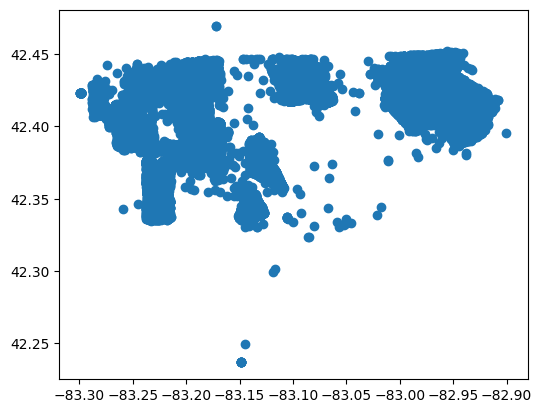

In [12]:
merged_geo.plot()

<Axes: >

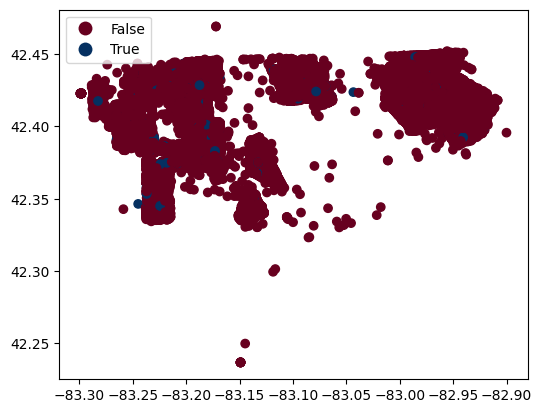

In [15]:
#visualize where most arrests and firearms seized were
merged_geo['arrest_made'] = merged_geo['arrests'] >= 1
merged_geo['gun_seized'] = merged_geo['firearms_recovered'] >= 1

merged_geo.plot(column='arrest_made', legend=True, cmap='RdBu')

In [16]:
#only show incidents where an arrest was made or gun was seized
arrest_or_gun_seized = merged_geo[(merged_geo['arrest_made'] == True) | (merged_geo['gun_seized'] == True)]
len(arrest_or_gun_seized)

1708

<Axes: >

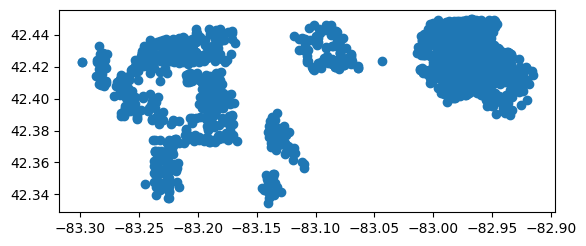

In [19]:
arrest_or_gun_seized.plot()

In [20]:
#output merged_geo file to geojson
merged_geo.to_file('data/shotspotter_incidents.geojson', driver='geojson')

In [24]:
#output just arrests/gun seized file to geojson
arrest_or_gun_seized.to_file('data/shotspotter_incidents_arrest_or_seizure.geojson', driver='geojson')